# Module 2c - From a Live Literature Search to a Dataset

Type a topic, pull the open-access papers for it, read their **full text**, and turn them into a clean table you can model. This first part does the harvest: **an OpenAlex filter you build on the website, pasted here, becomes a corpus of full-text PDFs downloaded and parsed automatically.**

**The live-demo flow**
1. On **openalex.org** search a topic and click filters until the page reads something like:
   *works where open access is (true) and year >= (2019) and title/abstract has (battery capacity mAh) and type is (article) and citation count >= (100)*
2. Copy the filter (the site shows the API query), paste it into the config cell below.
3. Run: the notebook pulls that corpus, downloads each open-access full-text PDF, and parses it.

No key and no login for any of this (OpenAlex is free; a courtesy email is optional).

**The 5 steps (you only edit the two marked EDIT):**
```
 OQL query  ->  OpenAlex corpus  ->  full-text PDFs  ->  LLM-extracted table  ->  capacity model
 (EDIT 1)       count + list         download+parse       (EDIT 2 defines it)      R2 + parity plot
```
Two bits of jargon: **OQL** = OpenAlex Query Language, the plain filter the openalex.org site writes when you click checkboxes. **OA** = open access, papers anyone can download legally - the only ones we fetch.

## 0. Setup

In [1]:
import sys, subprocess
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "requests", "pymupdf"])
import requests, re, io, time
print("ready")

ready


## 1. Paste your OpenAlex query (OQL)

Build the query on **openalex.org** by clicking filters. The builder writes it in **OQL** (OpenAlex Query Language), e.g.

```
works where citation count >= (100)
  and open access is (true)
  and year >= (2020)
  and title/abstract has (battery capacity and mAh)
  and type is (article)
```

**Copy that OQL and paste it below** - the notebook translates it into the OpenAlex API query. (It also accepts a full `api.openalex.org/works?...` URL or a raw filter string.)

In [2]:
import re
# ============ EDIT HERE (1 of 2): your OpenAlex query, built on openalex.org ============
# Paste the OQL exactly as the openalex.org builder writes it (or a URL / raw filter):
OQL = """
works where open access is (true)
  and year >= (2019)
  and title/abstract has (battery capacity and mAh)
  and type is (article)
"""

USE_CACHE = True   # True: read the shipped pre-crawled cache (offline, instant). False: crawl live.
N_PAPERS = 20                       # how many full-text papers to harvest (demo: 15-30)
MAILTO   = "ruiding@uchicago.edu"   # courtesy only, NOT a key; may be ""

# OQL display-name -> OpenAlex API filter key. Names whose key is just the snake_case
# of the name are handled by the fallback below, so any extra field a student adds
# on openalex.org keeps working; only genuinely unknown fields get a warning.
OQL_FIELDS = {
    "citation count": "cited_by_count", "cited by count": "cited_by_count",
    "year": "publication_year", "publication year": "publication_year",
    "open access": "open_access.is_oa", "is open access": "open_access.is_oa",
    "title/abstract": "title_and_abstract.search", "title and abstract": "title_and_abstract.search",
    "title": "title.search", "abstract": "abstract.search", "fulltext": "fulltext.search",
    "type": "type", "language": "language", "publication date": "publication_date",
    "is retracted": "is_retracted", "has doi": "has_doi",
    "has abstract": "has_abstract", "has fulltext": "has_fulltext",
}
SEARCHY = {"title_and_abstract.search", "title.search", "abstract.search", "fulltext.search"}

def parse_oql(text):
    """Translate OpenAlex OQL into an API filter. Also accepts a full openalex.org URL or raw filter."""
    t = text.strip()
    if "openalex.org" in t and "filter=" in t:
        from urllib.parse import urlparse, parse_qs, unquote
        return unquote(parse_qs(urlparse(t).query).get("filter", [""])[0])
    if ("where" not in t.lower()) and re.search(r"[a-z_]+\.[a-z_]+:", t):
        return t
    t = re.sub(r"^\s*works\s+where\s+", "", t, flags=re.I)
    parts, guessed = [], []
    for fld, op, val in re.findall(r"([a-zA-Z /_]+?)\s*(>=|<=|>|<|is not|is|has)\s*\(([^)]*)\)", t):
        fld = re.sub(r"^and\b\s*", "", fld.strip().lower()).strip(); val = val.strip()
        key = OQL_FIELDS.get(fld)
        if not key:                                   # fallback: name -> snake_case key
            key = re.sub(r"[ /]+", "_", fld); guessed.append(f"{fld} -> {key}")
        if key in SEARCHY:
            parts.append(f"{key}:" + re.sub(r"\s+and\s+", " ", val, flags=re.I)); continue
        v = val.lower() if val.lower() in ("true", "false") else val
        neg = "!" if op == "is not" else ""
        if op == ">=":   parts.append(f"{key}:>{int(val)-1}")
        elif op == "<=": parts.append(f"{key}:<{int(val)+1}")
        elif op == ">":  parts.append(f"{key}:>{val}")
        elif op == "<":  parts.append(f"{key}:<{val}")
        else:            parts.append(f"{key}:{neg}{v}")
    if guessed:
        print("  note: guessed these field keys (check OpenAlex docs if a query errors):", guessed)
    return ",".join(parts)

FILTER = parse_oql(OQL)
print("translated OQL -> OpenAlex filter:\n ", FILTER)

translated OQL -> OpenAlex filter:
  open_access.is_oa:true,publication_year:>2018,title_and_abstract.search:battery capacity mAh,type:article


## 2. Pull the corpus

Ask OpenAlex for works matching the filter, sorted by citations, and keep the ones that actually have a downloadable open-access PDF.

*Read-out: OpenAlex found this many matching papers (most-cited first); "have an OA PDF" is the subset we can actually download and read.*

In [3]:
import pandas as pd, gzip, json, os
CACHE = "cache"
def openalex_count(filt, mail=""):
    p={"filter":filt,"per-page":1}
    if mail: p["mailto"]=mail
    return requests.get("https://api.openalex.org/works", params=p, timeout=45).json()["meta"]["count"]
def get_corpus(filt, n, mail=""):
    base,out,cur="https://api.openalex.org/works",[], "*"
    while len(out)<n:
        p={"filter":filt,"sort":"cited_by_count:desc","per-page":min(200,n-len(out)),"cursor":cur}
        if mail: p["mailto"]=mail
        j=requests.get(base,params=p,timeout=60).json(); res=j.get("results",[])
        if not res: break
        for w in res:
            loc=w.get("best_oa_location") or {}
            out.append(dict(title=(w.get("title") or "")[:140],year=w.get("publication_year"),
                venue=(loc.get("source") or {}).get("display_name"),cited=w.get("cited_by_count"),
                doi=(w.get("doi") or "").replace("https://doi.org/",""),pdf=loc.get("pdf_url") or ""))
            if len(out)>=n: break
        cur=j.get("meta",{}).get("next_cursor")
        if not cur: break
        time.sleep(0.2)
    return out

N_LIST = 200     # size of the LIVE paper list (ignored in cache mode)
if USE_CACHE and os.path.exists(f"{CACHE}/corpus_papers.csv"):
    papers = pd.read_csv(f"{CACHE}/corpus_papers.csv").fillna("")
    corpus = papers.to_dict("records")
    n_pdf  = sum(1 for p in corpus if p["pdf"])
    print(f"[cache] loaded {len(corpus)} papers from the shipped pre-crawl ({n_pdf} with an OA PDF). Offline, instant.")
else:
    TOTAL = openalex_count(FILTER, MAILTO)
    print(f"your query matches {TOTAL:,} papers in OpenAlex.\n")
    corpus = get_corpus(FILTER, min(N_LIST, TOTAL), MAILTO)
    n_pdf  = sum(1 for p in corpus if p["pdf"])
    print(f"built a list of {len(corpus)} papers (of {TOTAL:,} total); {n_pdf} have a downloadable OA PDF.")
    papers = pd.DataFrame(corpus)
papers.head(10)

[cache] loaded 1500 papers from the shipped pre-crawl (1456 with an OA PDF). Offline, instant.


,title,year,venue,cited,doi,pdf
0,Zinc anode-compatible in-situ solid electrolyt...,2019,Nature Communications,953,10.1038/s41467-019-13436-3,https://www.nature.com/articles/s41467-019-134...
1,Enhanced Potassium-Ion Storage of the 3D Carbo...,2020,Nano-Micro Letters,894,10.1007/s40820-020-00525-y,https://link.springer.com/content/pdf/10.1007/...
2,Revealing the closed pore formation of waste w...,2023,Nature Communications,809,10.1038/s41467-023-39637-5,https://www.nature.com/articles/s41467-023-396...
3,Scalable synthesis of ant-nest-like bulk porou...,2019,Nature Communications,784,10.1038/s41467-019-09510-5,https://www.nature.com/articles/s41467-019-095...
4,Dendritic Nanostructured Waste Copper Wires fo...,2019,Nano-Micro Letters,771,10.1007/s40820-019-0337-2,https://link.springer.com/content/pdf/10.1007/...
5,Conductive 2D metal-organic framework for high...,2019,Nature Communications,690,10.1038/s41467-019-12857-4,https://www.nature.com/articles/s41467-019-128...
6,Theoretical Calculation Guided Design of Singl...,2019,The Australian Nuclear Science and Technology ...,606,10.1021/acs.nanolett.9b04719,https://apo.ansto.gov.au/bitstreams/c00897af-b...
7,Steric Effect Tuned Ion Solvation Enabling Sta...,2021,OSTI OAI (U.S. Department of Energy Office of ...,596,10.1021/jacs.1c09006,https://www.osti.gov/servlets/purl/1878520
8,MgO‐Template Synthesis of Extremely High Capac...,2020,Angewandte Chemie International Edition,579,10.1002/anie.202013951,https://onlinelibrary.wiley.com/doi/pdfdirect/...
9,Tuning the Kinetics of Zinc‐Ion Insertion/Extr...,2020,OSTI OAI (U.S. Department of Energy Office of ...,557,10.1002/adma.202001113,https://www.osti.gov/servlets/purl/1756167


### Download the paper list

Save the matching-paper list and pull it to your computer with one click (a browser download dialog on Colab).

In [4]:
# save the paper list and offer a one-click download to your computer
papers.to_csv("corpus_papers.csv", index=False)
papers.to_json("corpus_papers.json", orient="records", force_ascii=False, indent=1)
print("saved: corpus_papers.csv  /  corpus_papers.json")
if "google.colab" in sys.modules:
    from google.colab import files
    files.download("corpus_papers.csv")     # <- this pops a browser "save file" dialog
    # files.download("corpus_papers.json")  # uncomment to grab the JSON too
else:
    print("(on Colab this pops a download dialog; locally the files are just written next to the notebook)")

saved: corpus_papers.csv  /  corpus_papers.json
(on Colab this pops a download dialog; locally the files are just written next to the notebook)


## 3. Download and parse the full text

Each open-access PDF is downloaded (with a normal browser header) and parsed to text. A publisher that blocks automated download (some return HTTP 403) is skipped with a note; the rest go through.

*Expect some "skip (blocked)" lines - many publishers refuse automated downloads (HTTP 403). That's normal; we keep whatever comes through. This is the slow step in live mode.*

In [5]:
import gzip, json, os
N_FULLTEXT = 300  # LIVE only: how many PDFs to try (only ~1/4 download; slow). CACHE mode ignores this and loads ALL shipped full texts.
if USE_CACHE and os.path.exists(f"{CACHE}/fulltext.jsonl.gz"):
    texts=[json.loads(l) for l in gzip.open(f"{CACHE}/fulltext.jsonl.gz","rt")]
    print(f"[cache] loaded full text for {len(texts)} papers from the shipped pre-crawl. Offline, instant.")
else:
    import fitz
    UA={"User-Agent":"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120 Safari/537.36"}
    def full_text(u):
        r=requests.get(u,headers=UA,timeout=60)
        if r.status_code!=200 or not (r.content[:4]==b"%PDF" or "pdf" in r.headers.get("content-type","")): return None
        return "\n".join(pg.get_text() for pg in fitz.open(stream=r.content,filetype="pdf"))[:60000]
    todo=[p for p in corpus if p["pdf"]][:N_FULLTEXT]
    print(f"downloading full text for {len(todo)} papers (raise N_FULLTEXT for more; PDFs are the slow part)\n")
    texts=[]
    for p in todo:
        try: t=full_text(p["pdf"])
        except Exception: t=None
        if t: texts.append({**p,"nchars":len(t),"text":t}); print(f"  ok  {len(t):6d} chars  {str(p['venue'])[:34]}")
        else: print(f"  skip (blocked/not a PDF)   {str(p['venue'])[:34]}")
        time.sleep(0.4)
    print(f"\nfull text obtained for {len(texts)}/{len(todo)} papers")
print(f"\n-> {len(texts)} full-text papers ready for extraction (next part).")

[cache] loaded full text for 337 papers from the shipped pre-crawl. Offline, instant.

-> 337 full-text papers ready for extraction (next part).


## 4. Extract a structured table from the full texts

An LLM reads each full text and returns one record: the main material, its chemistry family and electrode role, the headline **specific capacity (mAh/g)**, and the conditions (current density, C-rate, cycles, voltage). This is the same idea as Module 2a, now on battery papers. Cache mode loads the shipped table; live mode calls the model (paste a DeepSeek key).

*This block is the one place to retarget the notebook to another field. `one-hot` = turning a label like anode/cathode into 0/1 columns a model can use; `CLASS_THRESHOLD` = the cut between "high" and "ordinary".*

In [6]:
import pandas as pd, os, json
DEEPSEEK_KEY = ""   # LIVE only: paste sk-... (DeepSeek). Cache mode needs no key.

# ============================  EDIT HERE (2 of 2): what to extract & model  ============================
# One definition drives BOTH the extraction prompt AND the model, so they can never fall out of sync.
# Change these lines to point the WHOLE notebook at your field. Nothing below needs editing.
DOMAIN      = "battery"                       # the kind of paper (used in the prompt)
TARGET      = "specific_capacity_mAh_g"       # the ONE numeric column to predict (goes LAST in the table)
CATEGORICAL = ["material_class", "chemistry_family", "electrode_role", "cell_type"]  # -> one-hot in the model
NUMERIC     = ["current_density_A_g", "C_rate", "cycle_number", "upper_cutoff_V",    # -> used as numbers
               "lower_cutoff_V", "temperature_C", "loading_mg_cm2", "first_cycle_CE_percent"]
HINTS = {   # a short hint per field to guide the LLM (allowed values / units)
    "material_class":   "sulfur|silicon|graphite|hard-carbon|NMC|NCA|LFP|LCO|V2O5|MnO2|Li-metal|Na-metal|Zn-metal|other",
    "chemistry_family": "Li-ion|Na-ion|K-ion|Zn-ion|Li-S|Li-metal|Mg-ion|Ca-ion|Al-ion|other",
    "electrode_role":   "cathode|anode|other",
    "cell_type":        "half-cell|full-cell|other",
    "specific_capacity_mAh_g": "reversible gravimetric specific capacity in mAh/g (not areal)",
    "current_density_A_g": "in A/g", "C_rate": "e.g. 0.2 for 0.2C", "cycle_number": "integer",
    "upper_cutoff_V": "V", "lower_cutoff_V": "V", "temperature_C": "deg C",
    "loading_mg_cm2": "mg/cm2", "first_cycle_CE_percent": "percent",
}
CLASS_THRESHOLD = 500   # classification: TARGET above this = "high", else "conventional"
# =======================================================================================================

assert TARGET not in CATEGORICAL + NUMERIC, 'TARGET must not also be listed as a feature'
COLS = CATEGORICAL + NUMERIC + [TARGET]        # target LAST -> the CSV drops straight into Module 1d
def build_prompt():
    fields = ",\n".join(f'  "{f}": <{HINTS.get(f, "value")}, or null>' for f in COLS)
    return (f"Extract ONE record from this {DOMAIN} paper's full text. Return ONLY a JSON object "
            f"(use null if a field is not stated):\n{{\n{fields}\n}}\n"
            f"Rules: use only values stated in the text; numeric fields must be plain numbers; output JSON only.")
PROMPT = build_prompt()

if USE_CACHE and os.path.exists("cache/battery_dataset.csv"):
    data = pd.read_csv("cache/battery_dataset.csv")
    print(f"[cache] loaded the extracted dataset: {len(data)} rows "
          f"({data[TARGET].notna().sum()} with a value for {TARGET}).")
else:
    from concurrent.futures import ThreadPoolExecutor
    def extract_one(p):
        body={"model":"deepseek-v4-flash","temperature":0,"thinking":{"type":"disabled"},"max_tokens":700,
              "response_format":{"type":"json_object"},
              "messages":[{"role":"user","content":PROMPT+"\n\nPAPER:\n"+p["text"][:45000]}]}
        try:
            r=requests.post("https://api.deepseek.com/chat/completions",
                headers={"Authorization":f"Bearer {DEEPSEEK_KEY}","Content-Type":"application/json"},
                data=json.dumps(body),timeout=120)
            return json.loads(r.json()["choices"][0]["message"]["content"])
        except Exception: return {}
    with ThreadPoolExecutor(max_workers=8) as ex:
        rows=list(ex.map(extract_one, texts))
    data=pd.DataFrame(rows)
    data.insert(0,'doi',[t.get('doi','') for t in texts][:len(data)])
    data=data.reindex(columns=['doi']+COLS)
    print(f"extracted {len(data)} rows ({data[TARGET].notna().sum()} with a value for {TARGET}).")

print("\n--- the prompt built from your field definition (edit the block above to change it) ---")
print(PROMPT)
data.head(8)

[cache] loaded the extracted dataset: 295 rows (295 with a value for specific_capacity_mAh_g).

--- the prompt built from your field definition (edit the block above to change it) ---
Extract ONE record from this battery paper's full text. Return ONLY a JSON object (use null if a field is not stated):
{
  "material_class": <sulfur|silicon|graphite|hard-carbon|NMC|NCA|LFP|LCO|V2O5|MnO2|Li-metal|Na-metal|Zn-metal|other, or null>,
  "chemistry_family": <Li-ion|Na-ion|K-ion|Zn-ion|Li-S|Li-metal|Mg-ion|Ca-ion|Al-ion|other, or null>,
  "electrode_role": <cathode|anode|other, or null>,
  "cell_type": <half-cell|full-cell|other, or null>,
  "current_density_A_g": <in A/g, or null>,
  "C_rate": <e.g. 0.2 for 0.2C, or null>,
  "cycle_number": <integer, or null>,
  "upper_cutoff_V": <V, or null>,
  "lower_cutoff_V": <V, or null>,
  "temperature_C": <deg C, or null>,
  "loading_mg_cm2": <mg/cm2, or null>,
  "first_cycle_CE_percent": <percent, or null>,
  "specific_capacity_mAh_g": <reversible grav

,doi,material_class,chemistry_family,electrode_role,cell_type,current_density_A_g,C_rate,cycle_number,upper_cutoff_V,lower_cutoff_V,temperature_C,loading_mg_cm2,first_cycle_CE_percent,specific_capacity_mAh_g
0,10.1038/s41467-019-13436-3,V2O5,Zn-ion,cathode,full-cell,0.60,NaN,800.0,NaN,NaN,NaN,NaN,NaN,110.0
1,10.1038/s41467-019-09510-5,silicon,Li-ion,anode,half-cell,NaN,0.5,1000.0,NaN,NaN,NaN,0.8,80.3,1271.0
2,10.1038/s41467-023-39637-5,hard-carbon,Na-ion,anode,half-cell,0.02,NaN,NaN,NaN,NaN,30.0,1.8,NaN,430.0
3,10.1038/s41467-019-12857-4,other,Zn-ion,cathode,full-cell,0.05,NaN,NaN,1.3,0.50,25.0,2.0,NaN,228.0
4,10.1002/adma.202001113,V2O5,Zn-ion,cathode,half-cell,1.00,NaN,1.0,1.6,0.20,25.0,NaN,NaN,398.8
5,10.1038/s41467-020-15217-9,silicon,Li-ion,anode,half-cell,NaN,NaN,1500.0,1.5,0.02,NaN,NaN,NaN,1500.0
6,10.1038/s41467-022-30939-8,other-oxide,Zn-ion,cathode,full-cell,1.00,NaN,1000.0,NaN,NaN,25.0,16.0,NaN,90.0
7,10.1038/s41467-019-13739-5,other,Na-ion,cathode,half-cell,0.02,NaN,100.0,3.6,1.00,NaN,NaN,NaN,452.0


### See what you harvested

Before modeling, look at the table: how many papers survived each step, what one paper becomes, and what the numbers look like.

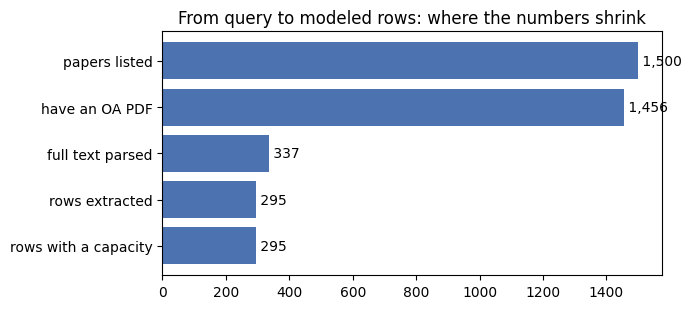

Normal attrition: publishers block some downloads, some PDFs don't parse, some papers state no capacity. You model what survives.


In [7]:
import matplotlib.pyplot as plt
# how the numbers shrink from query to modeled rows (real data always has attrition)
stages=["papers listed","have an OA PDF","full text parsed","rows extracted","rows with a capacity"]
counts=[len(corpus), n_pdf, len(texts), len(data), int(data[TARGET].notna().sum())]
fig,ax=plt.subplots(figsize=(7,3.2)); ax.barh(range(len(stages)),counts,color="#4C72B0"); ax.invert_yaxis()
ax.set_yticks(range(len(stages))); ax.set_yticklabels(stages)
for i,c in enumerate(counts): ax.text(c,i,f" {c:,}",va="center")
ax.set_title("From query to modeled rows: where the numbers shrink"); plt.tight_layout(); plt.show()
print("Normal attrition: publishers block some downloads, some PDFs don't parse, some papers state no capacity. You model what survives.")

In [8]:
import json
# one real paper in -> one record out (matched by DOI)
row=data.dropna(subset=[TARGET]).iloc[0]
paper=next((t for t in texts if t.get("doi")==row["doi"]), texts[0])
print("ONE PAPER (first ~600 chars of its full text):\n"); print(paper["text"][:600],"...\n")
print("-> ONE RECORD the LLM pulled from it:\n")
print(json.dumps({k:row[k] for k in row.index if k!="doi" and pd.notna(row[k])}, indent=2, default=str))

ONE PAPER (first ~600 chars of its full text):

ARTICLE
Zinc anode-compatible in-situ solid electrolyte
interphase via cation solvation modulation
Huayu Qiu1,2,4, Xiaofan Du1,4, Jingwen Zhao1*, Yantao Wang1, Jiangwei Ju1, Zheng Chen1, Zhenglin Hu1,
Dongpeng Yan
3, Xinhong Zhou2* & Guanglei Cui1*
The surface chemistry of solid electrolyte interphase is one of the critical factors that govern
the cycling life of rechargeable batteries. However, this chemistry is less explored for zinc
anodes, owing to their relatively high redox potential and limited choices in electrolyte. Here,
we report the observation of a zinc ﬂuoride-rich organic/inorga ...

-> ONE RECORD the LLM pulled from it:

{
  "material_class": "V2O5",
  "chemistry_family": "Zn-ion",
  "electrode_role": "cathode",
  "cell_type": "full-cell",
  "current_density_A_g": 0.6,
  "cycle_number": 800.0,
  "specific_capacity_mAh_g": 110.0
}


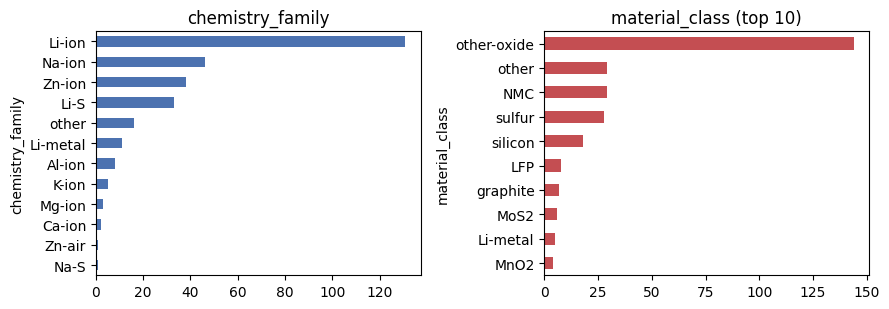

Sanity check: the LLM produced sensible material/chemistry labels, not garbage.


In [9]:
fig,ax=plt.subplots(1,2,figsize=(9,3.2))
data["chemistry_family"].value_counts().plot.barh(ax=ax[0],color="#4C72B0"); ax[0].invert_yaxis(); ax[0].set_title("chemistry_family")
data["material_class"].value_counts().head(10).plot.barh(ax=ax[1],color="#C44E52"); ax[1].invert_yaxis(); ax[1].set_title("material_class (top 10)")
plt.tight_layout(); plt.show()
print("Sanity check: the LLM produced sensible material/chemistry labels, not garbage.")

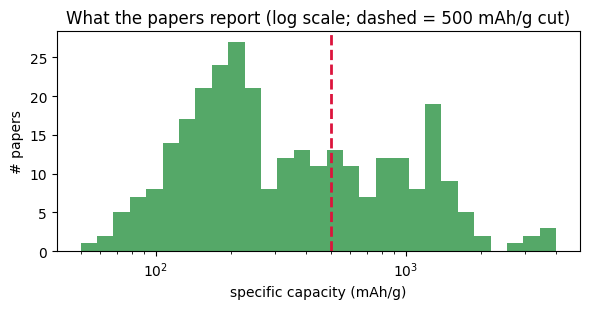

Values are lopsided across ~50-4000 mAh/g -> we model log10(capacity). Right of the red line = 'high-capacity' in the classifier.


In [10]:
import numpy as np, matplotlib.pyplot as plt
cap=pd.to_numeric(data[TARGET],errors="coerce").dropna()
fig,ax=plt.subplots(figsize=(6,3.2))
ax.hist(cap,bins=np.logspace(np.log10(50),np.log10(4000),30),color="#55A868")
ax.axvline(CLASS_THRESHOLD,color="crimson",ls="--",lw=2); ax.set_xscale("log")
ax.set(xlabel="specific capacity (mAh/g)",ylabel="# papers",
       title=f"What the papers report (log scale; dashed = {CLASS_THRESHOLD} mAh/g cut)")
plt.tight_layout(); plt.show()
print(f"Values are lopsided across ~50-4000 mAh/g -> we model log10(capacity). Right of the red line = 'high-capacity' in the classifier.")

### Download the dataset

One click to save the extracted table (`battery_dataset.csv`) to your computer.

In [11]:
data.to_csv("battery_dataset.csv", index=False)
data.reindex(columns=COLS).to_json("battery_dataset.json", orient="records", indent=1, force_ascii=False)
print("saved: battery_dataset.csv / battery_dataset.json")
if "google.colab" in sys.modules:
    from google.colab import files
    files.download("battery_dataset.csv")
else:
    print("(on Colab this pops a download dialog)")

saved: battery_dataset.csv / battery_dataset.json
(on Colab this pops a download dialog)


## 5. Close the loop: model the table (into Module 1)

The literature table now feeds the same kind of model as Module 1: one-hot the chemistry / electrode columns, keep the numeric conditions, and predict **specific capacity**. This is literature to dataset to model, end to end.

REGRESSION  predict specific_capacity_mAh_g (log10)   test R2 = 0.720   (n_core=265)
CLASSIFICATION  specific_capacity_mAh_g > 500 (high vs conventional)   test accuracy = 0.868  (baseline 0.64)


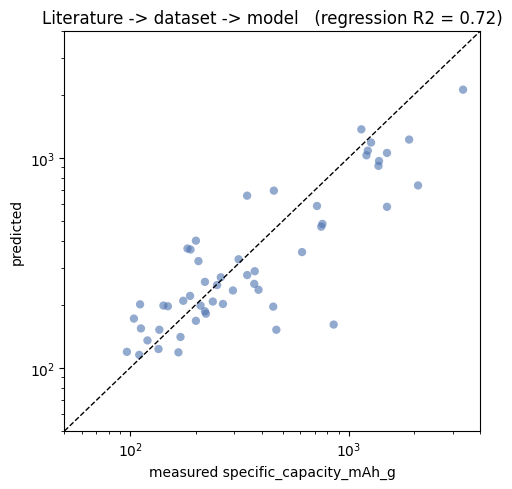

top drivers: ['chemistry_family_Li-S', 'upper_cutoff_V', 'electrode_role_anode', 'cycle_number', 'material_class_silicon', 'lower_cutoff_V']


In [12]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, accuracy_score
SEED = 0   # one 80/20 split, same style as Modules 1a-1d

d = data[data[TARGET].notna()].copy()
cap = pd.to_numeric(d[TARGET], errors="coerce")
d = d[cap.between(1, 4000)]                       # physical bound; drops rare parse outliers

# set aside some papers as a BRAND-NEW hold-out the model never sees (Section 6).
# adaptive so a small live run (few papers) still works instead of crashing.
n_hold  = min(30, len(d)//5)
holdout = d.sample(n_hold, random_state=1) if n_hold>=5 else d.iloc[0:0]
core    = d.drop(holdout.index)

cats = [c for c in CATEGORICAL if c in data.columns]
nums = [c for c in NUMERIC if c in data.columns]
def make_X(df):
    Xx = pd.get_dummies(df[cats], columns=cats, dummy_na=True)
    for n in nums: Xx[n] = pd.to_numeric(df[n], errors="coerce")
    for n in [c for c in ("current_density_A_g","cycle_number") if c in Xx]:
        Xx[n] = np.log1p(Xx[n].clip(lower=0))
    return Xx
Xcore = make_X(core); MED = Xcore.median(numeric_only=True); Xcore = Xcore.fillna(MED).fillna(0.0)
capc = pd.to_numeric(core[TARGET]); y = np.log10(capc); yc = (capc > CLASS_THRESHOLD).astype(int)

# headline numbers: one 80/20 split on the core set
Xtr,Xte,ytr,yte = train_test_split(Xcore, y, test_size=0.2, random_state=SEED)
rf  = RandomForestRegressor(n_estimators=500, random_state=0, n_jobs=-1).fit(Xtr, ytr)
xgb = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=0).fit(Xtr, ytr)
R2  = r2_score(yte, (rf.predict(Xte)+xgb.predict(Xte))/2)
Xa,Xb,ya,yb = train_test_split(Xcore, yc, test_size=0.2, random_state=SEED, stratify=yc)
acc = accuracy_score(yb, RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1).fit(Xa,ya).predict(Xb))
print(f"REGRESSION  predict {TARGET} (log10)   test R2 = {R2:.3f}   (n_core={len(core)})")
print(f"CLASSIFICATION  {TARGET} > {CLASS_THRESHOLD} (high vs conventional)   test accuracy = {acc:.3f}  "
      f"(baseline {yb.value_counts(normalize=True).max():.2f})")

fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(10**yte, 10**((rf.predict(Xte)+xgb.predict(Xte))/2), alpha=.6, color="#4C72B0", edgecolor="none")
lim=[50,4000]; ax.plot(lim,lim,"k--",lw=1)
ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim, xlabel=f"measured {TARGET}", ylabel="predicted",
       title=f"Literature -> dataset -> model   (regression R2 = {R2:.2f})")
os.makedirs("figures", exist_ok=True); fig.tight_layout(); fig.savefig("figures/2c_capacity_parity.png", dpi=140); plt.show()

# final models trained on ALL of core, for the brand-new hold-out in Section 6
rfF  = RandomForestRegressor(n_estimators=500, random_state=0, n_jobs=-1).fit(Xcore, y)
xgbF = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=0).fit(Xcore, y)
clfF = RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1).fit(Xcore, yc)
print("top drivers:", list(pd.Series(rfF.feature_importances_, index=Xcore.columns).nlargest(6).index))

**What these numbers mean**
- **R² (regression):** 0 = no better than guessing the average, 1 = perfect. ~0.74 means the columns explain most (not all) of the capacity - good for messy literature data.
- **Baseline (classification):** the score from always guessing the most common class (~0.64). Our ~0.90 is well above it, so the model really learned something.
- **Parity plot:** each dot is one paper, measured (x) vs predicted (y); dots near the dashed line are good. Axes are log because capacities span 50-4000 mAh/g - the same reason we predict log10(capacity).

## 6. Predict brand-new papers (never seen in training or test)

The real test of generalization: 30 papers were **set aside at the start** and used in neither training nor the test split. The model has never seen them. We now predict their capacity and compare to what the papers actually report - especially the high-vs-conventional call.

In [13]:
if len(holdout)==0:
    print('Not enough papers for a brand-new hold-out. In live mode raise N_FULLTEXT (a few hundred), or use cache mode.')
else:
    Xh = make_X(holdout).reindex(columns=Xcore.columns, fill_value=0).fillna(MED).fillna(0.0)
    caph = pd.to_numeric(holdout[TARGET], errors="coerce")
    true_hi = (caph > CLASS_THRESHOLD).astype(int)
    pred_hi = clfF.predict(Xh)
    pred_cap = 10 ** ((rfF.predict(Xh) + xgbF.predict(Xh)) / 2)
    
    res = pd.DataFrame({
        "chemistry":  holdout["chemistry_family"].values,
        "material":   holdout["material_class"].values,
        "true mAh/g": caph.round(0).astype(int).values,
        "pred mAh/g": np.round(pred_cap).astype(int),
        "true class": np.where(true_hi.values==1, "high", "conv"),
        "pred class": np.where(pred_hi==1, "high", "conv"),
        "ok":         np.where(pred_hi==true_hi.values, "yes", "NO"),
    })
    print(res.head(15).to_string(index=False))
    acc_new = (pred_hi==true_hi.values).mean()
    r2_new  = r2_score(np.log10(caph), (rfF.predict(Xh)+xgbF.predict(Xh))/2)
    print(f"\nOn {len(holdout)} brand-new papers (never in training or test):")
    print(f"   high-vs-conventional classification accuracy = {acc_new:.2f}")
    print(f"   capacity regression R2 (log10)               = {r2_new:.2f}")

chemistry    material  true mAh/g  pred mAh/g true class pred class  ok
   Zn-air    Zn-metal         812         472       high       high yes
   Na-ion other-oxide         123         153       conv       conv yes
   Li-ion    graphite         360         311       conv       conv yes
   Na-ion other-oxide         400         186       conv       conv yes
   Li-ion other-oxide         450         727       conv       high  NO
     Li-S      sulfur        1375        1160       high       high yes
 Li-metal other-oxide         210         223       conv       conv yes
    other other-oxide         116         425       conv       conv yes
   Li-ion         NMC         214         184       conv       conv yes
   Na-ion       other         139         131       conv       conv yes
     Li-S other-oxide        1218        1142       high       high yes
     Li-S      sulfur         940         627       high       high yes
   Li-ion         LFP         120         158       conv       c

## What you built

A closed loop, all from a topic: **OQL search -> open-access corpus -> full text -> an LLM-extracted table -> a model of specific capacity.** Change the OQL to your own field and the whole pipeline follows. The pre-crawled cache lets it run offline in seconds; live mode does it for real with a DeepSeek key.